![Alt text](https://imgur.com/orZWHly.png=80)
source: @allison_horst https://github.com/allisonhorst/penguins

You have been asked to support a team of researchers who have been collecting data about penguins in Antartica! The data is available in csv-Format as `penguins.csv`

**Origin of this data** : Data were collected and made available by Dr. Kristen Gorman and the Palmer Station, Antarctica LTER, a member of the Long Term Ecological Research Network.

**The dataset consists of 5 columns.**

Column | Description
--- | ---
culmen_length_mm | culmen length (mm)
culmen_depth_mm | culmen depth (mm)
flipper_length_mm | flipper length (mm)
body_mass_g | body mass (g)
sex | penguin sex

Unfortunately, they have not been able to record the species of penguin, but they know that there are **at least three** species that are native to the region: **Adelie**, **Chinstrap**, and **Gentoo**.  Your task is to apply your data science skills to help them identify groups in the dataset!

   culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g     sex
0              39.1             18.7              181.0       3750.0    MALE
1              39.5             17.4              186.0       3800.0  FEMALE
2              40.3             18.0              195.0       3250.0  FEMALE
3              36.7             19.3              193.0       3450.0  FEMALE
4              39.3             20.6              190.0       3650.0    MALE


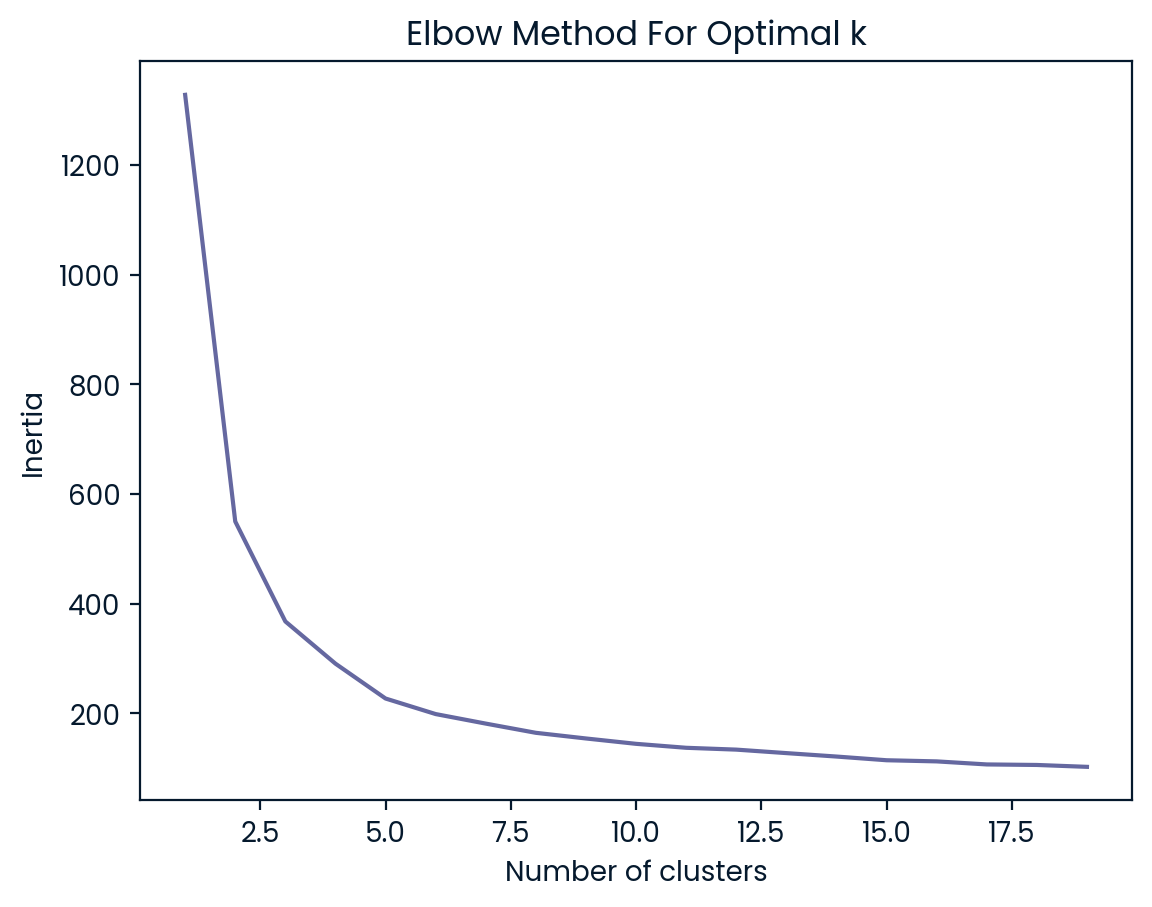

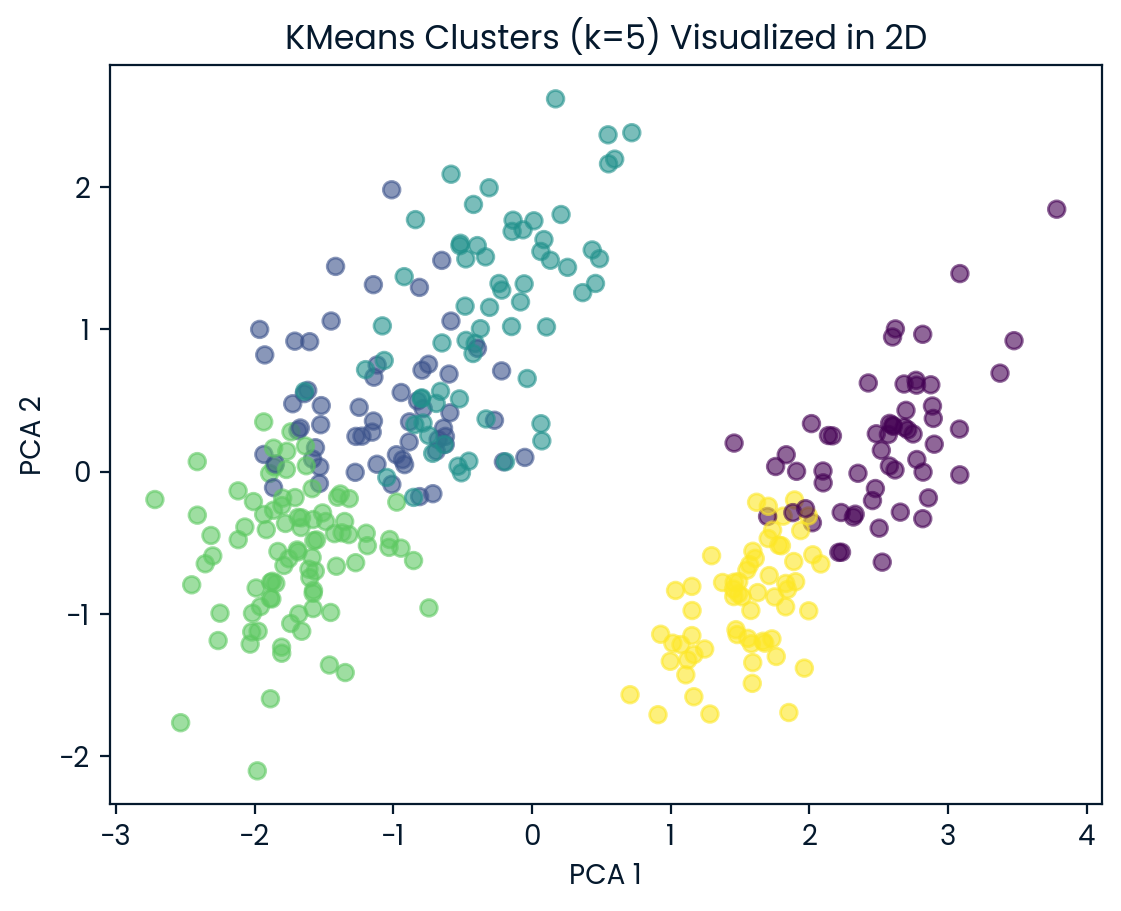

In [20]:
# Import Required Packages
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

# Loading and examining the dataset
penguins_df = pd.read_csv("penguins.csv")
print(penguins_df.head())

dummies = pd.get_dummies(penguins_df)

dummies = dummies.drop([col for col in dummies.columns if col.startswith('sex_')], axis=1)

scaler = StandardScaler()
dumies_norms = scaler.fit_transform(dummies)

# Evaluating optimal number of clusters
inertia = []

# Fix: Use range to get integer values for k
K = range(1, 20,1)

# performing optimal number of clusters
for k in K:
    model = KMeans(n_clusters = k, random_state = 42).fit(dumies_norms)
    inertia.append(model.inertia_)

plt.figure()
plt.plot(K,inertia)
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

# Fit KMeans with optimal number of clusters (example: 5)
model_opt = KMeans(n_clusters=5,random_state=42).fit(dumies_norms)

# Get the cluster labels for each data point
labels = model_opt.labels_

# reduction to 2D using PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(dumies_norms)

plt.figure()
plt.scatter(reduced_data[:,0], reduced_data[:,1], c=labels, cmap='viridis', alpha=0.6)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('KMeans Clusters (k=5) Visualized in 2D')
plt.show()

# final statical DataFrame for each cluster
numeric_columns = penguins_df.select_dtypes(include=np.number).columns.tolist()
penguins_df["label"] = model_opt.labels_
stat_penguins = (
    penguins_df
    .groupby("label")[numeric_columns]
    .mean()
)
